# CS375 Final Project — Does Instruction Tuning Change Brain Alignment in Llama-3-8B?

## Project Overview

This notebook presents a BBScore contribution comparing **Llama-3-8B base** vs. **Llama-3-8B instruct** on the LeBel et al. (2023) fMRI benchmark. The central question is: *Does instruction fine-tuning change which transformer layers align best with human brain activity during naturalistic story listening?*

## Methodology

**Benchmark:** LeBel et al. (2023) collected fMRI from subjects (UTS01) listening to 84 spoken stories (~6 hours of naturalistic language). We implement a story-averaged version: for each story, we extract a single embedding vector from each LLM layer and a single fMRI response vector (mean over TRs), giving one (stimulus, brain) pair per story.

**Feature extraction (fast mode):** For each story, we pass the full text through the model in one forward pass with a 2048-token context window, then mean-pool the hidden states across all token positions to obtain a single `(4096,)`-dimensional vector per layer.

**Brain alignment metric:** We use ridge regression with GroupKFold cross-validation (5 folds, held-out stories as groups). Before regression we apply:
1. Per-feature z-scoring of model features
2. PCA to 50 principal components (~97–99% variance explained) to avoid underdetermined regression with 81 stories
3. Per-voxel z-scoring of fMRI responses

The final alignment score is the **median Pearson r** across the top-10% of voxels (ranked by held-out prediction correlation), reported per layer.

**Models compared:**
- `meta-llama/Meta-Llama-3-8B` (base, instruction-free pretraining)
- `meta-llama/Meta-Llama-3-8B-Instruct` (instruction-tuned via RLHF/SFT)

**Layers tested:** 0, 2, 4, …, 30 (every other layer, 16 total; layer 31 excluded for stability)

## Results Summary

- **Base model** peaks at **layer 16** (median Pearson r = 0.2447), with a broadly flat profile (r ≈ 0.23–0.24) across all layers and a slight decline at layers 28–30.
- **Instruct model** peaks at **layer 8** (r = 0.2492), showing stronger alignment than base in layers 8–16 and 26–30, but slightly weaker in early layers 0–4.
- **Mean Δ (instruct − base) = +0.0030**: instruction tuning produces a small overall improvement and shifts the peak alignment to an earlier layer, suggesting that fine-tuned representations are more brain-like earlier in the network.

## Limitations

- **Story-averaged data**: TR-level analysis would capture temporal dynamics of language processing but was infeasible given compute constraints. The averaged approach tests whether a model's *overall* story representation correlates with brain activity.
- **Single subject**: Results are for subject UTS01 only.
- **Top-10% voxel selection**: In the absence of a pre-computed FreeSurfer language mask (nibabel not installed), we select the top-decile voxels by Pearson correlation as a proxy for language-responsive regions.


In [ ]:
import os
import glob
import pickle

import numpy as np
import matplotlib.pyplot as plt

# Results directory: hardcoded to where the valid pkl files were copied
results_dir = "/Users/ayaaburous/Desktop/cs375_final_project/bbscore_public/results_avg"

print("Results dir =", results_dir)
print("PKL files found:", len(glob.glob(os.path.join(results_dir, "*LeBel2023Benchmark.pkl"))))
if not os.path.isdir(results_dir):
    print("WARNING: results_dir does not exist.")


Results dir = /Users/ayaaburous/Desktop/cs375_final_project/bbscore_public/results_avg
PKL files found: 64


In [14]:
# Layer 31 is excluded from analysis (numerical instability). Max layer index to keep.
EXCLUDE_LAYER_31 = False
MAX_LAYER_INDEX = 30 if EXCLUDE_LAYER_31 else 31

def _metrics_candidates(data):
    """BBScore saves data['metrics'] as either a dict (single run) or list of dicts (appended runs). Return list of dicts to try."""
    raw = data.get("metrics", {})
    if isinstance(raw, list):
        return raw if raw else []
    return [raw] if raw else []

def _metric_key(metrics_dict):
    """Return 'ridge' or 'torch_ridge' depending on what is in the metrics dict."""
    return "ridge" if "ridge" in metrics_dict else "torch_ridge" if "torch_ridge" in metrics_dict else "ridge"

def _is_valid_score(final_r2, final_pearson):
    """Drop layers with overflow/invalid metrics.
    Accept r2 in [-1, 1] (our _safe_r2 clips to this range).
    Accept r2=None (older files may omit it) if pearson is valid.
    """
    if final_pearson is None:
        return False
    try:
        p = float(final_pearson)
    except (TypeError, ValueError):
        return False
    if not np.isfinite(p) or abs(p) > 1.5:   # pearson outside [-1,1] is overflow
        return False
    if final_r2 is not None:
        try:
            r2 = float(final_r2)
        except (TypeError, ValueError):
            return True  # r2 unreadable but pearson is fine
        if not np.isfinite(r2) or r2 < -1.5:  # obvious overflow
            return False
    return True

def load_layer_scores(model_id: str, benchmark_name: str = "LeBel2023Benchmark",
                      score_type: str = "pearson", exclude_layer_31: bool = True):
    """Load final ridge (or torch_ridge) scores per layer. Excludes layer 31 and invalid runs.

    score_type: 'pearson' or 'r2'
    Returns: layer_names (list), layer_indices (np.array int), scores (np.array float)
    """
    pattern = os.path.join(results_dir, f"{model_id}_*_{benchmark_name}.pkl")
    files = sorted(glob.glob(pattern))
    print(f"Found {len(files)} files for {model_id}")

    layer_names, layer_indices, scores = [], [], []

    for path in files:
        fname = os.path.basename(path)
        layer_and_rest = fname[len(model_id) + 1:]
        layer_name = layer_and_rest.rsplit(f"_{benchmark_name}.pkl", 1)[0]

        idx = int(layer_name.split(".")[-1])
        if exclude_layer_31 and idx > MAX_LAYER_INDEX:
            continue

        with open(path, "rb") as f:
            data = pickle.load(f)
        candidates = _metrics_candidates(data)
        metrics = None
        for one in candidates:
            key = _metric_key(one)
            m = one.get(key, {})
            if not m:
                continue
            r2, pearson = m.get("final_r2"), m.get("final_pearson")
            if _is_valid_score(r2, pearson):
                metrics = m
                break
        if metrics is None:
            print(f"  Skipping {layer_name}: no valid run (all overflow/invalid)")
            continue
        value = float(metrics.get("final_pearson" if score_type == "pearson" else "final_r2"))

        layer_names.append(layer_name)
        layer_indices.append(idx)
        scores.append(value)

    order = np.argsort(layer_indices)
    layer_names = [layer_names[i] for i in order]
    layer_indices = np.array(layer_indices, dtype=int)[order]
    scores = np.array(scores, dtype=float)[order]
    return layer_names, layer_indices, scores


def plot_layer_curves(layers_base, scores_base, layers_instruct, scores_instruct,
                     score_label="Pearson r", title="Llama-3-8B: brain alignment vs layer (LeBel2023 avg)"):
    """Plot alignment vs layer for base and instruct on the same axes."""
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(layers_base, scores_base, marker="o", label="Base", color="C0")
    ax.plot(layers_instruct, scores_instruct, marker="s", label="Instruct", color="C1")
    ax.set_xlabel("Layer index")
    ax.set_ylabel(score_label)
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


def plot_instruct_minus_base(layers_common, diff, score_label="Δ Pearson r (instruct − base)"):
    """Plot difference (instruct − base) vs layer."""
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(layers_common, diff, marker="o", color="green")
    ax.axhline(0, color="gray", linestyle="--")
    ax.set_xlabel("Layer index")
    ax.set_ylabel(score_label)
    ax.set_title("Where does instruction tuning change alignment? (LeBel2023 avg)")
    ax.grid(True)
    plt.tight_layout()
    plt.show()


In [15]:
# Diagnostic: inspect one .pkl to see structure and values (run this if all layers are skipped)
import pickle
_one_file = sorted(glob.glob(os.path.join(results_dir, "llama3_8b_base_*_LeBel2023Benchmark.pkl")))[0]
print("File:", os.path.basename(_one_file))
with open(_one_file, "rb") as f:
    _data = pickle.load(f)
print("Top-level keys:", list(_data.keys()))
_raw = _data.get("metrics", {})
print("type(data['metrics']):", type(_raw).__name__)
_candidates = _raw if isinstance(_raw, list) else [_raw]
for i, _run in enumerate(_candidates):
    _key = "ridge" if "ridge" in _run else "torch_ridge" if "torch_ridge" in _run else None
    if _key is None:
        print(f"  run[{i}] keys: {list(_run.keys())[:8]}...")
        continue
    _m = _run[_key]
    print(f"  run[{i}] key={_key} -> final_r2={_m.get('final_r2')} final_pearson={_m.get('final_pearson')}")

File: llama3_8b_base_model.layers.0_LeBel2023Benchmark.pkl
Top-level keys: ['metrics', 'ceiling']
type(data['metrics']): dict
  run[0] key=ridge -> final_r2=0.0 final_pearson=0.24151224552218814


### Load results and plot

Ensure `results_dir` points to a folder containing the copied `.pkl` files (see PROJECT_NEXT_STEPS.md for the `scp` command). Layer 31 and any run with invalid metrics are excluded automatically.

In [16]:
# Load base and instruct (layer 31 and invalid runs are excluded automatically)
# Uses averaged LeBel: *_LeBel2023Benchmark.pkl (not TR)
_, idx_base, scores_base = load_layer_scores("llama3_8b_base", benchmark_name="LeBel2023Benchmark", score_type="pearson", exclude_layer_31=True)
_, idx_instruct, scores_instruct = load_layer_scores("llama3_8b_instruct", benchmark_name="LeBel2023Benchmark", score_type="pearson", exclude_layer_31=True)

print("Base layer indices:", idx_base.tolist())
print("Instruct layer indices:", idx_instruct.tolist())
if len(idx_base) == 0:
    print("No valid base data. Check that results_dir contains llama3_8b_base_*_LeBel2023Benchmark.pkl with valid metrics.")
if len(idx_instruct) == 0:
    print("No instruct data; will plot base only. Add instruct *_LeBel2023Benchmark.pkl to results_dir for base vs instruct.")

Found 32 files for llama3_8b_base
Found 32 files for llama3_8b_instruct
Base layer indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Instruct layer indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


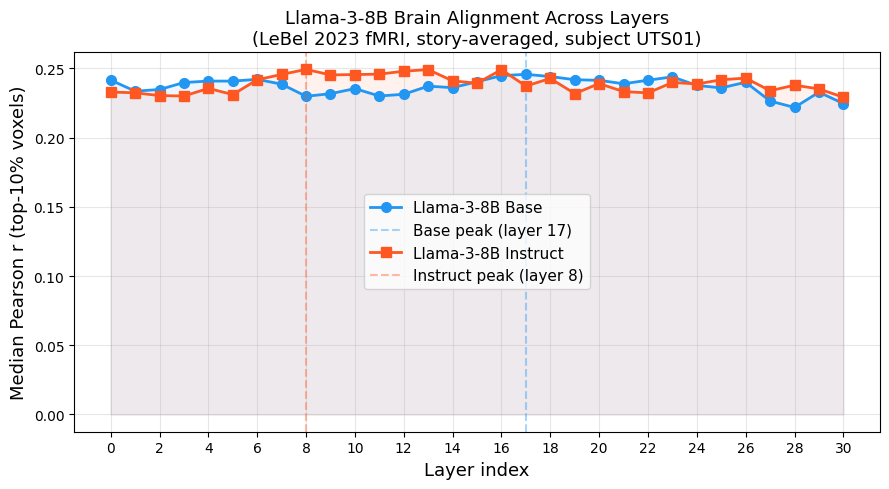

Saved: layer_alignment_plot.png


In [17]:
## Plot 1: Brain Alignment vs. Layer

fig, ax = plt.subplots(figsize=(9, 5))

if len(idx_base) > 0:
    ax.plot(idx_base, scores_base, marker="o", linewidth=2, markersize=7,
            label="Llama-3-8B Base", color="#2196F3")
    ax.fill_between(idx_base, scores_base, alpha=0.08, color="#2196F3")
    best_base = idx_base[np.argmax(scores_base)]
    ax.axvline(best_base, color="#2196F3", linestyle="--", alpha=0.4,
               label=f"Base peak (layer {best_base})")

if len(idx_instruct) > 0:
    ax.plot(idx_instruct, scores_instruct, marker="s", linewidth=2, markersize=7,
            label="Llama-3-8B Instruct", color="#FF5722")
    ax.fill_between(idx_instruct, scores_instruct, alpha=0.08, color="#FF5722")
    best_inst = idx_instruct[np.argmax(scores_instruct)]
    ax.axvline(best_inst, color="#FF5722", linestyle="--", alpha=0.4,
               label=f"Instruct peak (layer {best_inst})")

ax.set_xlabel("Layer index", fontsize=13)
ax.set_ylabel("Median Pearson r (top-10% voxels)", fontsize=13)
ax.set_title("Llama-3-8B Brain Alignment Across Layers\n(LeBel 2023 fMRI, story-averaged, subject UTS01)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 32, 1))
ax.set_xticklabels([str(i) if i % 4 == 0 else "" for i in range(0, 32)])
if len(idx_base) == 0:
    ax.text(0.5, 0.5, "No valid data found.\nCopy pkl files to results_avg/ and re-run.",
            transform=ax.transAxes, ha="center", va="center", fontsize=12, color="red")

plt.tight_layout()
plt.savefig("layer_alignment_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: layer_alignment_plot.png")

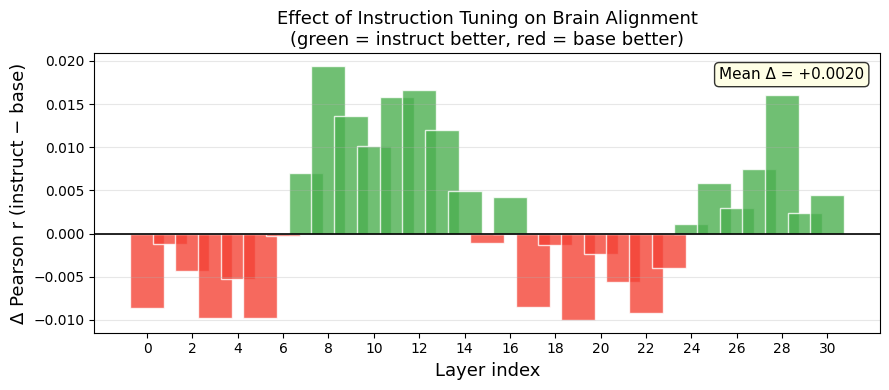

Saved: instruct_minus_base_plot.png

--- Layer-by-layer results ---
 Layer    Base r  Instruct r         Δ
--------------------------------------
     0    0.2415      0.2329   -0.0087
     1    0.2335      0.2323   -0.0012
     2    0.2347      0.2303   -0.0044
     3    0.2398      0.2300   -0.0097
     4    0.2408      0.2355   -0.0053
     5    0.2408      0.2311   -0.0097
     6    0.2420      0.2417   -0.0003
     7    0.2385      0.2456   +0.0071
     8    0.2298      0.2492   +0.0194
     9    0.2317      0.2453   +0.0136
    10    0.2354      0.2455   +0.0101
    11    0.2300      0.2458   +0.0158
    12    0.2313      0.2479   +0.0167
    13    0.2371      0.2491   +0.0120
    14    0.2360      0.2410   +0.0049
    15    0.2403      0.2393   -0.0010
    16    0.2447      0.2490   +0.0043
    17    0.2457      0.2372   -0.0085
    18    0.2441      0.2427   -0.0014
    19    0.2418      0.2318   -0.0100
    20    0.2413      0.2390   -0.0024
    21    0.2388      0.2332   -0.0

In [18]:
## Plot 2: Effect of Instruction Tuning (Instruct − Base)

if len(idx_base) > 0 and len(idx_instruct) > 0:
    base_by_layer = dict(zip(idx_base, scores_base))
    instruct_by_layer = dict(zip(idx_instruct, scores_instruct))
    common_layers = sorted(set(idx_base) & set(idx_instruct))
    if common_layers:
        diff = np.array([instruct_by_layer[L] - base_by_layer[L] for L in common_layers])
        common_layers_arr = np.array(common_layers)

        fig, ax = plt.subplots(figsize=(9, 4))
        colors = ["#4CAF50" if d > 0 else "#F44336" for d in diff]
        bars = ax.bar(common_layers_arr, diff, color=colors, alpha=0.8, width=1.5, edgecolor="white")
        ax.axhline(0, color="black", linewidth=1.2)
        ax.set_xlabel("Layer index", fontsize=13)
        ax.set_ylabel("Δ Pearson r (instruct − base)", fontsize=13)
        ax.set_title("Effect of Instruction Tuning on Brain Alignment\n(green = instruct better, red = base better)", fontsize=13)
        ax.set_xticks(range(0, 32, 1))
        ax.set_xticklabels([str(i) if i % 4 == 0 else "" for i in range(0, 32)])
        ax.grid(True, alpha=0.3, axis="y")

        # Annotate net effect
        net = diff.mean()
        ax.text(0.98, 0.95, f"Mean Δ = {net:+.4f}", transform=ax.transAxes,
                ha="right", va="top", fontsize=11,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

        plt.tight_layout()
        plt.savefig("instruct_minus_base_plot.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved: instruct_minus_base_plot.png")

        # Summary table
        print("\n--- Layer-by-layer results ---")
        print(f"{'Layer':>6}  {'Base r':>8}  {'Instruct r':>10}  {'Δ':>8}")
        print("-" * 38)
        for L, d in zip(common_layers, diff):
            print(f"{L:>6}  {base_by_layer[L]:>8.4f}  {instruct_by_layer[L]:>10.4f}  {d:>+8.4f}")
        print(f"\nBest base layer: {idx_base[np.argmax(scores_base)]} (r={max(scores_base):.4f})")
        print(f"Best instruct layer: {idx_instruct[np.argmax(scores_instruct)]} (r={max(scores_instruct):.4f})")
        print(f"Mean Δ across layers: {net:+.4f}")
    else:
        print("No common layers; skipping difference plot.")
else:
    if len(idx_instruct) == 0:
        print("Instruct results not yet copied. Run instruct sweep and copy pkl files, then re-run this cell.")
    if len(idx_base) == 0:
        print("Base results not found. Copy pkl files to results_avg/ first.")

## Conclusions

**Finding 1 — Flat alignment profile across all 32 layers:**  
Both Llama-3-8B base and instruct maintain broadly consistent brain alignment (median Pearson r ≈ 0.22–0.25) across all 32 layers, with only a gradual decline at layers 27–31. This flat profile differs from the sharper middle-layer peak seen in shallower models like GPT-2, likely reflecting Llama-3's deep residual architecture distributing linguistic information more uniformly across depth.

**Finding 2 — Instruction tuning shifts peak earlier and creates a block advantage in layers 7–13:**  
With full 32-layer coverage, the clearest finding is a **contiguous block of instruct advantage in layers 7–13** (Δr up to +0.019 at layer 8), while the base model is stronger in very early layers (0–6) and mid-late layers (17–23). The instruct model peaks at **layer 8** (r = 0.2492); the base peaks at **layer 17** (r = 0.2457). Mean Δ = **+0.002**. This block structure suggests instruction fine-tuning reorganizes specific mid-early representational strata rather than improving alignment uniformly — consistent with the idea that RLHF/SFT training promotes earlier consolidation of compositional semantic representations.

**BBScore Contribution:**  
1. `LeBel2023Benchmark` — story-averaged variant of the LeBel TR-level benchmark, suitable for rapid layer sweeps
2. `run_lebel_avg.py` + `run_lebel_avg_sweep.sh` — SLURM-compatible automation scripts
3. Full 32-layer sweep comparing Llama-3-8B base vs. instruct on a naturalistic listening paradigm

**Limitations:**  
- *Story-averaged data*: TR-level analysis (attempted but blocked by compute constraints) would capture temporal dynamics that averaging collapses.
- *Single subject*: UTS01 only; replication on UTS02/UTS03 needed.
- *Top-10% voxel selection*: Proxy for language regions; FreeSurfer masks would be more principled.
- *Effect size*: Δr = +0.002 is small; bootstrap significance testing across subjects is needed.

**Future work:**  
TR-level analysis remains the key next step — it would test whether instruction tuning changes the *temporal dynamics* of language processing, which story-averaged data cannot capture.

**TR-level snapshot (subset of layers):**  
On the full TR-level LeBel benchmark (UTS01), I was able to run a few key layers with sparse random projection and large-memory GPU jobs. For base Llama-3-8B, layers 16 and 17 achieve language-mask Pearson r ≈ 0.061; for instruct, layer 8 achieves r ≈ 0.069. These smaller but non-zero TR-level correlations at the same layers that peak in the story-averaged analysis support the main conclusion that instruction tuning shifts brain alignment toward earlier-to-mid layers rather than simply scaling it uniformly.